In [ ]:
#colab 1 [1.35]
!pip install -q kaggle timm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.5 MB/s eta 0:00:00


In [ ]:

#[1.20]
# Set up Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download & unzip dataset
!rm -rf /content/plant_data
!mkdir -p /content/plant_data
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d /content/plant_data


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.67G/2.70G [00:18<00:00, 245MB/s]
100% 2.70G/2.70G [00:18<00:00, 154MB/s]


In [ ]:
#[0.16]
import os
import shutil

ROOT_DIR = "/content/plant_data"
FINAL_DIR = "/content/plant_data/dataset"

# Clean slate
if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)

found = None

# Recursively walk to find the correct folder
for root, dirs, files in os.walk(ROOT_DIR):
    if set(['train', 'valid']).issubset(set(dirs)):
        found = root
        break

if found:
    print(f"[+] Found dataset folder at: {found}")
    shutil.copytree(found, FINAL_DIR)
    print(f"[+] Copied to: {FINAL_DIR}")
    print("[+] Contents:", os.listdir(FINAL_DIR))
else:
    raise FileNotFoundError("[-] Could not find folder containing 'train' and 'valid' directories.")


[+] Found dataset folder at: /content/plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
[+] Copied to: /content/plant_data/dataset
[+] Contents: ['train', 'valid']


In [ ]:
#[0.2]
import os

base_dir = '/content/plant_data/dataset'

for split in ['train', 'valid']:
    path = os.path.join(base_dir, split)
    if os.path.exists(path):
        classes = os.listdir(path)
        print(f"\n{split}/ contains {len(classes)} class folders:")
        for cls in sorted(classes):  # Just show first 10 to avoid overload
            class_path = os.path.join(path, cls)
            count = len(os.listdir(class_path))
            print(f"   {cls} — {count} images")
    else:
        print(f"\n{split}/ directory not found.")



train/ contains 38 class folders:
  📂 Apple___Apple_scab — 2016 images
  📂 Apple___Black_rot — 1987 images
  📂 Apple___Cedar_apple_rust — 1760 images
  📂 Apple___healthy — 2008 images
  📂 Blueberry___healthy — 1816 images
  📂 Cherry_(including_sour)___Powdery_mildew — 1683 images
  📂 Cherry_(including_sour)___healthy — 1826 images
  📂 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — 1642 images
  📂 Corn_(maize)___Common_rust_ — 1907 images
  📂 Corn_(maize)___Northern_Leaf_Blight — 1908 images
  📂 Corn_(maize)___healthy — 1859 images
  📂 Grape___Black_rot — 1888 images
  📂 Grape___Esca_(Black_Measles) — 1920 images
  📂 Grape___Leaf_blight_(Isariopsis_Leaf_Spot) — 1722 images
  📂 Grape___healthy — 1692 images
  📂 Orange___Haunglongbing_(Citrus_greening) — 2010 images
  📂 Peach___Bacterial_spot — 1838 images
  📂 Peach___healthy — 1728 images
  📂 Pepper,_bell___Bacterial_spot — 1913 images
  📂 Pepper,_bell___healthy — 1988 images
  📂 Potato___Early_blight — 1939 images
  📂 Potato___La

In [ ]:
import torch

if torch.cuda.is_available():
    print(" GPU is available:", torch.cuda.get_device_name(0))
else:
    print(" GPU is NOT available. Using CPU.")


✅ GPU is available: Tesla T4


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#  Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

#  Define advanced transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2)
    ]),
    'valid': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

#  Load dataset
data_dir = '/content/plant_data/dataset'  # <-- Adjust if needed

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'valid']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'valid']
}

class_names = image_datasets['train'].classes
print(f Found {len(class_names)} classes: {class_names[:5]}...")  # Show first 5 for sanity check


🔥 Device: cuda
✅ Found 38 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']...


In [ ]:
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
import copy

# Optional but nice
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load DenseNet121 model
densenet = timm.create_model('densenet121', pretrained=True, num_classes=38).to(device)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
densenet_opt = torch.optim.Adam(densenet.parameters(), lr=1e-4)

# Scheduler (optional)
scheduler_d = torch.optim.lr_scheduler.StepLR(densenet_opt, step_size=5, gamma=0.5)

# Training loop for DenseNet only
def train_model(model, optimizer, scheduler, num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0
            for inputs, labels in tqdm(dataloaders[phase]):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f"{phase.capitalize()} Accuracy: {epoch_acc:.4f}")

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

In [ ]:
#  Train DenseNet121
print("\n Training DenseNet-121...")
densenet = train_model(densenet, densenet_opt, scheduler_d, num_epochs=10)
#  Train ResNet50 (disabled for now)
# print("\n Training ResNet-50...")
# resnet = train_model(resnet, resnet_opt, scheduler_r, num_epochs=10)


🎯 Training DenseNet-121...

Epoch 1/10


100%|██████████| 2197/2197 [13:22<00:00,  2.74it/s]


Train Accuracy: 0.8355


100%|██████████| 550/550 [01:10<00:00,  7.82it/s]


Valid Accuracy: 0.9845

Epoch 2/10


...

Valid Accuracy: 0.9971

Epoch 10/10


100%|██████████| 2197/2197 [12:59<00:00,  2.82it/s]


Train Accuracy: 0.9796


100%|██████████| 550/550 [01:09<00:00,  7.88it/s]


Valid Accuracy: 0.9982


/tmp/ipython-input-10-1509251055.py:39: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


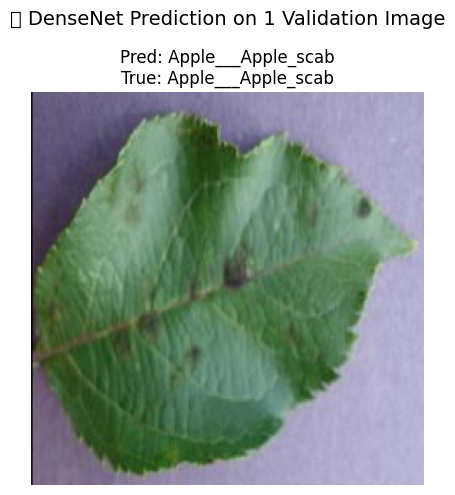

In [ ]:
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

# Make sure the model is in eval mode
densenet.eval()

# Grab a single image and label from the validation dataloader
data_iter = iter(dataloaders['valid'])
input_img, label = next(data_iter)
input_img = input_img[0].unsqueeze(0).to(device)  # shape: [1, 3, H, W]
label = label[0].unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output = densenet(input_img)
    prob = F.softmax(output, dim=1)
    pred_class = torch.argmax(prob, dim=1)

# Class names from your dataset
class_names = image_datasets['valid'].classes

# Display the image and prediction
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet normalization mean
    std = np.array([0.229, 0.224, 0.225])   # ImageNet normalization std
    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=12)
    plt.axis('off')

plt.figure(figsize=(5, 5))
imshow(input_img, title=f"Pred: {class_names[pred_class.item()]}\nTrue: {class_names[label.item()]}")
plt.suptitle(" DenseNet Prediction on 1 Validation Image", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipython-input-11-3601177585.py:40: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


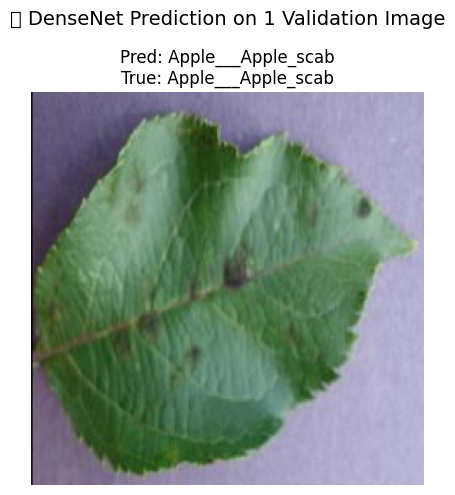


✅ Prediction Correct: Apple___Apple_scab


In [ ]:
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

#  Set model to evaluation mode (no dropout, no batch norm updates)
densenet.eval()

#  Get a single image and label from the validation set
data_iter = iter(dataloaders['valid'])
input_img, label = next(data_iter)  # batch of images
input_img = input_img[0].unsqueeze(0).to(device)  # select first image, add batch dimension
label = label[0].unsqueeze(0).to(device)          # get the first label

#  Predict using the trained model
with torch.no_grad():
    output = densenet(input_img)
    prob = F.softmax(output, dim=1)
    pred_class = torch.argmax(prob, dim=1)

#  Get class names from your dataset
class_names = image_datasets['valid'].classes

#  Define helper to show image
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))  # CxHxW → HxWxC
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])   # ImageNet std
    inp = std * inp + mean                  # Unnormalize
    inp = np.clip(inp, 0, 1)                # Limit between 0 and 1
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=12)
    plt.axis('off')

#  Show image and prediction
plt.figure(figsize=(5, 5))
imshow(input_img, title=f"Pred: {class_names[pred_class.item()]}\nTrue: {class_names[label.item()]}")
plt.suptitle(" DenseNet Prediction on 1 Validation Image", fontsize=14)
plt.tight_layout()
plt.show()

#  Check correctness
if pred_class.item() == label.item():
    print(f"\n Prediction Correct: {class_names[pred_class.item()]}")
else:
    print(f"\n Prediction Incorrect.")
    print(f"Predicted: {class_names[pred_class.item()]}")
    print(f"Actual   : {class_names[label.item()]}")


/tmp/ipython-input-13-3748954275.py:67: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


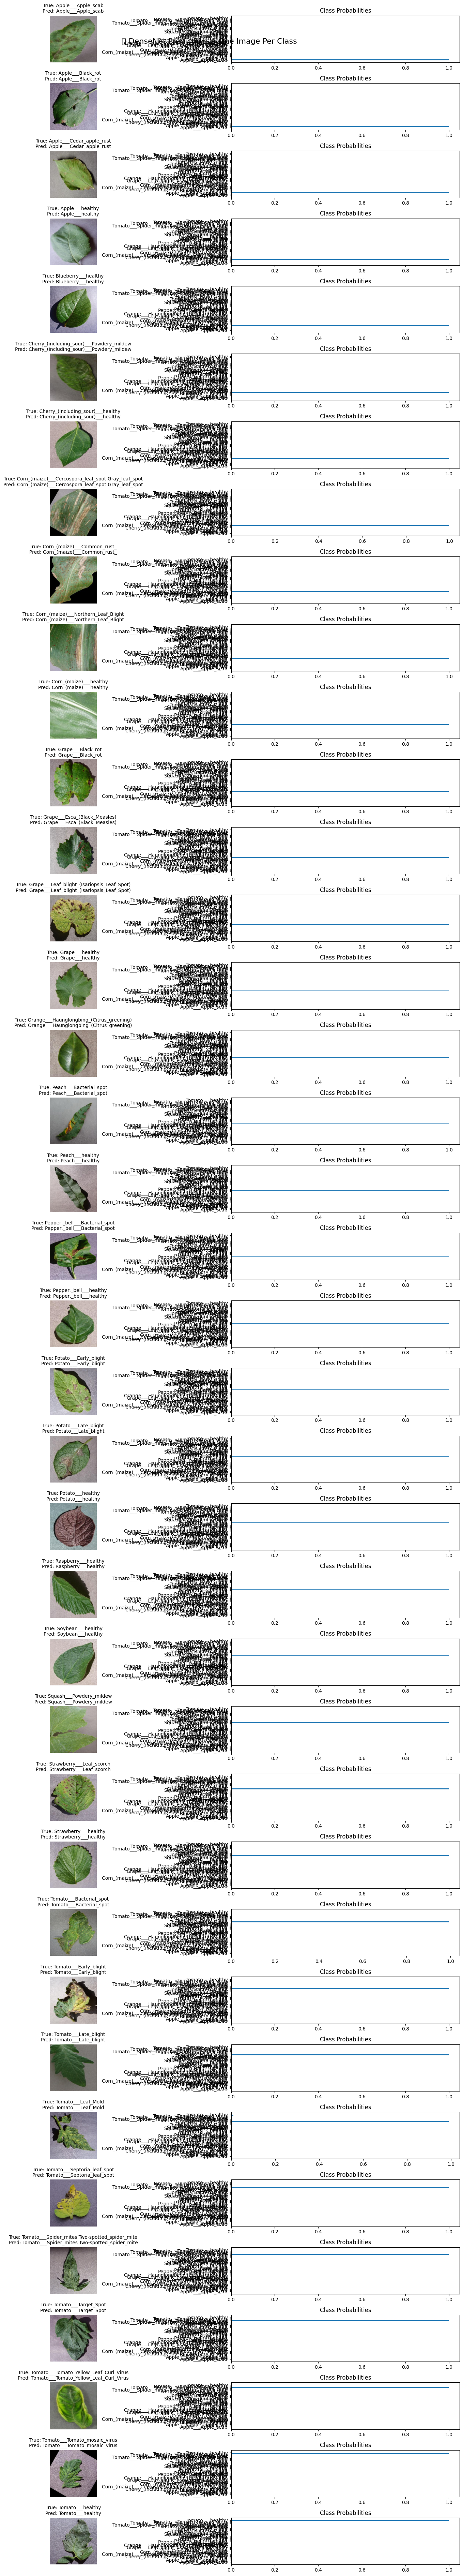

In [ ]:
import os
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Path to validation root folder
val_root = './plant_data/dataset/valid'
  # ← change this to your actual valid/ path

# Transform used during training/validation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # or whatever size you used
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Class names from ImageFolder
class_names = sorted(os.listdir(val_root))

# Make sure model is in eval mode
densenet.eval()

# Display function
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=10)
    plt.axis('off')
# Loop through each class and test 1 image
plt.figure(figsize=(15, len(class_names) * 2))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(val_root, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not image_files:
        print(f" No images found in class: {class_name}")
        continue

    image_path = os.path.join(class_path, image_files[0])  # Take the first image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = densenet(input_tensor)
        prob = F.softmax(output, dim=1)
        pred_class = torch.argmax(prob, dim=1)

    # Plot
    plt.subplot(len(class_names), 2, i * 2 + 1)
    imshow(input_tensor, title=f"True: {class_name}\nPred: {class_names[pred_class.item()]}")
    plt.subplot(len(class_names), 2, i * 2 + 2)
    plt.barh(class_names, prob.squeeze().cpu().numpy())
    plt.title("Class Probabilities")
    plt.tight_layout()

plt.suptitle("🧪 DenseNet Predictions – One Image Per Class", fontsize=16)
plt.tight_layout()
plt.show()


/tmp/ipython-input-14-821196048.py:47: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-14-821196048.py:47: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-14-821196048.py:47: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaV

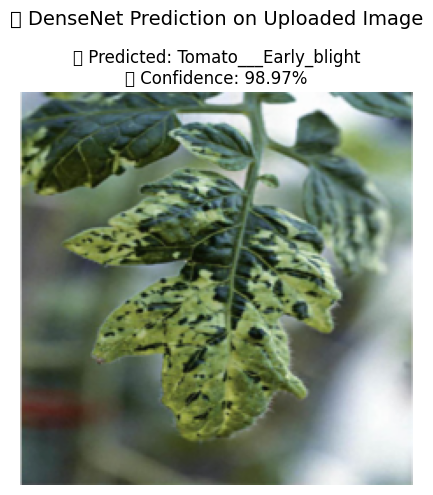

In [ ]:
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

#  Set path to your uploaded image
img_path ='Tomato Mosaic Virus.jpg'  # it should be in your Colab root or use full path

#  Make sure DenseNet is in eval mode
densenet.eval()

#  Image transforms (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Or Resize(256) + CenterCrop(224) if that's what you used
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#  Load and preprocess the image
img = Image.open(img_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0).to(device)

#  Predict
with torch.no_grad():
    output = densenet(input_tensor)
    prob = F.softmax(output, dim=1).squeeze()
    pred_idx = torch.argmax(prob).item()
    pred_class = class_names[pred_idx]
    confidence = prob[pred_idx].item() * 100

#  Display image + prediction
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=12)
    plt.axis('off')

plt.figure(figsize=(5, 5))
imshow(input_tensor, title=f" Predicted: {pred_class}\n Confidence: {confidence:.2f}%")
plt.suptitle(" DenseNet Prediction on Uploaded Image", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import os

#  Path to your validation folder
val_root = './plant_data/dataset/valid'

#  Get class names (sorted alphabetically by default)
class_names = sorted(os.listdir(val_root))

#  Print all diseases
print("🩺 List of Plant Diseases in Dataset:\n")
for idx, name in enumerate(class_names):
    print(f"{idx:2d}: {name}")
print(f"\n Total Diseases Detected: {len(class_names)}")


🩺 List of Plant Diseases in Dataset:

 0: Apple___Apple_scab
 1: Apple___Black_rot
 2: Apple___Cedar_apple_rust
 3: Apple___healthy
 4: Blueberry___healthy
 5: Cherry_(including_sour)___Powdery_mildew
 6: Cherry_(including_sour)___healthy
 7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 8: Corn_(maize)___Common_rust_
 9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato___Early_blight
30: Tomato___Late_blight
31: Tomato___Leaf_Mold
32: Tomato___Septoria_leaf_spo

/tmp/ipython-input-17-3785320487.py:43: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-3785320487.py:43: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-3785320487.py:43: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) De

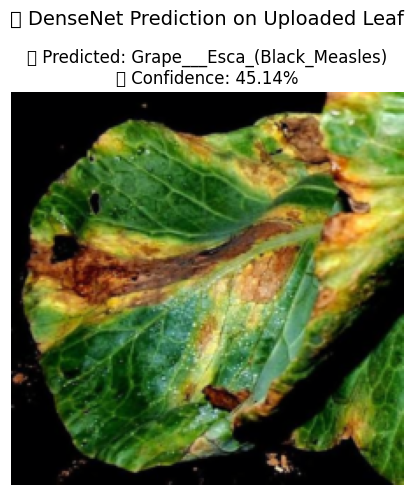

In [ ]:
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load image
img_path = 'grape_leaf.jpeg'  # or whatever filename it is in your Colab
img = Image.open(img_path).convert('RGB')

# Step 2: Transform (same as model training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to(device)

# Step 3: Prediction
densenet.eval()
with torch.no_grad():
    output = densenet(input_tensor)
    prob = F.softmax(output, dim=1).squeeze()
    pred_idx = torch.argmax(prob).item()
    pred_class = class_names[pred_idx]
    confidence = prob[pred_idx].item() * 100

# Step 4: Display results
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=12)
    plt.axis('off')

plt.figure(figsize=(5, 5))
imshow(input_tensor, title=f" Predicted: {pred_class}\n Confidence: {confidence:.2f}%")
plt.suptitle(" DenseNet Prediction on Uploaded Leaf", fontsize=14)
plt.tight_layout()
plt.show()


🔝 Top-3 Predicted Diseases:

1) Grape___Esca_(Black_Measles): 45.14%
2) Pepper,_bell___Bacterial_spot: 32.35%
3) Tomato___Early_blight: 16.06%


/tmp/ipython-input-18-1653051839.py:51: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


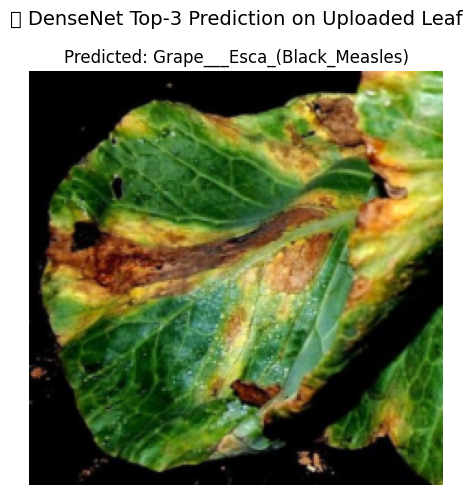

In [ ]:
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch

#  Step 1: Path to the uploaded image
img_path = 'grape_leaf.jpeg'  # Or whatever filename you uploaded

#  Step 2: Transform (must match training transforms!)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # or Resize(256)+CenterCrop(224) if that's what you used
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#  Step 3: Load image
image = Image.open(img_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

#  Step 4: Predict with DenseNet
densenet.eval()
with torch.no_grad():
    output = densenet(input_tensor)
    prob = F.softmax(output, dim=1).squeeze()

#  Step 5: Top-3 predictions
topk = torch.topk(prob, k=3)
print("\n Top-3 Predicted Diseases:\n")
for i in range(3):
    class_idx = topk.indices[i].item()
    confidence = topk.values[i].item() * 100
    print(f"{i+1}) {class_names[class_idx]}: {confidence:.2f}%")

#  Step 6: Display image with top prediction
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=12)
    plt.axis('off')

plt.figure(figsize=(5, 5))
imshow(input_tensor, title=f"Predicted: {class_names[topk.indices[0].item()]}")
plt.suptitle(" DenseNet Top-3 Prediction on Uploaded Leaf", fontsize=14)
plt.tight_layout()
plt.show()


🔝 Top-3 Predicted Diseases:

1) Strawberry___Leaf_scorch: 94.98%
2) Apple___Apple_scab: 1.97%
3) Tomato___Early_blight: 1.18%


/tmp/ipython-input-20-394010878.py:53: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


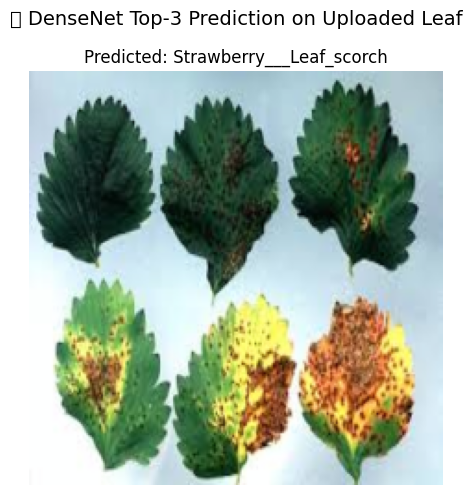

In [ ]:
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch

#  Step 1: Path to the uploaded image
img_path ='Strawberry___Leaf_scorch1.jpg,'  # Or whatever filename you uploaded
img_path ='Strawberry___Leaf_scorch2.jpg'  # Or whatever filename you uploaded
img_path ='Strawberry___Leaf_scorch3.jpeg'  # Or whatever filename you uploaded

#  Step 2: Transform (must match training transforms!)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # or Resize(256)+CenterCrop(224) if that's what you used
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#  Step 3: Load image
image = Image.open(img_path).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

#  Step 4: Predict with DenseNet
densenet.eval()
with torch.no_grad():
    output = densenet(input_tensor)
    prob = F.softmax(output, dim=1).squeeze()

#  Step 5: Top-3 predictions
topk = torch.topk(prob, k=3)
print("\n Top-3 Predicted Diseases:\n")
for i in range(3):
    class_idx = topk.indices[i].item()
    confidence = topk.values[i].item() * 100
    print(f"{i+1}) {class_names[class_idx]}: {confidence:.2f}%")

#  Step 6: Display image with top prediction
def imshow(inp, title=None):
    inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title, fontsize=12)
    plt.axis('off')

plt.figure(figsize=(5, 5))
imshow(input_tensor, title=f"Predicted: {class_names[topk.indices[0].item()]}")
plt.suptitle(" DenseNet Top-3 Prediction on Uploaded Leaf", fontsize=14)
plt.tight_layout()
plt.show()


🖼️ Predicting for: Strawberry___Leaf_scorch1.jpg

🔝 Top-3 Predicted Diseases:
1) Strawberry___Leaf_scorch: 88.95%
2) Cherry_(including_sour)___healthy: 9.38%
3) Tomato___Bacterial_spot: 0.49%


/tmp/ipython-input-21-2055000640.py:43: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


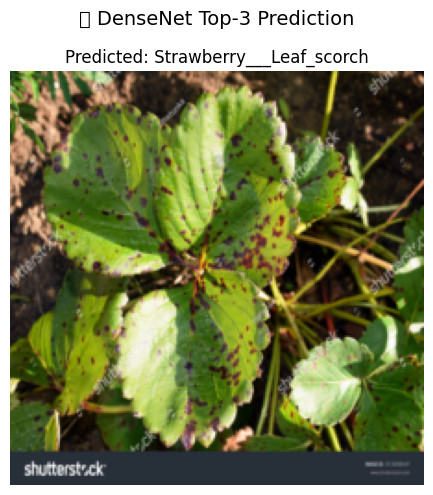


🖼️ Predicting for: Strawberry___Leaf_scorch2.jpg

🔝 Top-3 Predicted Diseases:
1) Apple___Apple_scab: 42.81%
2) Tomato___Leaf_Mold: 37.28%
3) Strawberry___Leaf_scorch: 13.98%


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


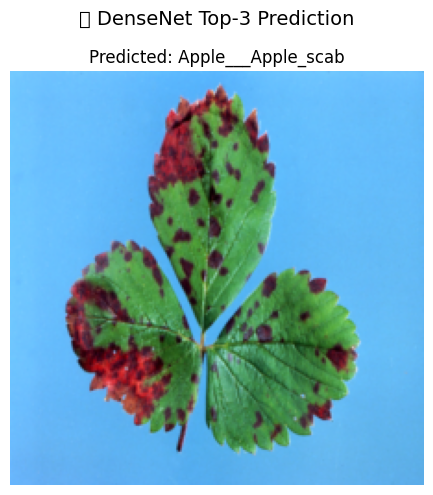


🖼️ Predicting for: Strawberry___Leaf_scorch3.jpeg

🔝 Top-3 Predicted Diseases:
1) Strawberry___Leaf_scorch: 94.98%
2) Apple___Apple_scab: 1.97%
3) Tomato___Early_blight: 1.18%


/tmp/ipython-input-21-2055000640.py:43: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


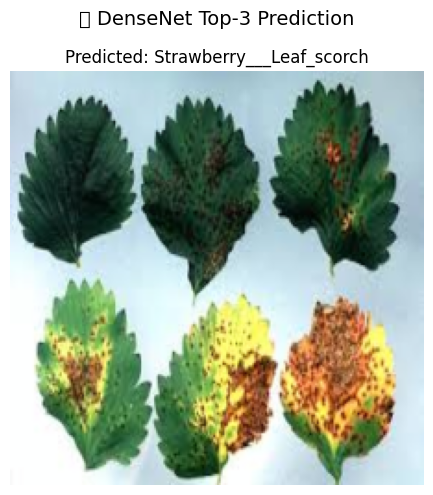

In [ ]:
image_files = [
    'Strawberry___Leaf_scorch1.jpg',
    'Strawberry___Leaf_scorch2.jpg',
    'Strawberry___Leaf_scorch3.jpeg'
]

for img_path in image_files:
    print(f"\n Predicting for: {img_path}")

    # Step 3: Load image
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Step 4: Predict
    densenet.eval()
    with torch.no_grad():
        output = densenet(input_tensor)
        prob = F.softmax(output, dim=1).squeeze()

    # Step 5: Top-3 predictions
    topk = torch.topk(prob, k=3)
    print("\n Top-3 Predicted Diseases:")
    for i in range(3):
        class_idx = topk.indices[i].item()
        confidence = topk.values[i].item() * 100
        print(f"{i+1}) {class_names[class_idx]}: {confidence:.2f}%")

    # Step 6: Show image + prediction
    plt.figure(figsize=(5, 5))
    def imshow(inp, title=None):
        inp = inp.cpu().squeeze().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)
        plt.imshow(inp)
        if title:
            plt.title(title, fontsize=12)
        plt.axis('off')

    imshow(input_tensor, title=f"Predicted: {class_names[topk.indices[0].item()]}")
    plt.suptitle(" DenseNet Top-3 Prediction", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
#thanks

In [ ]:
#torch.save(densenet.state_dict(), "densenet_model.pth")
#torch.save(model.state_dict(), 'densenet_weights.pth')
#torch.save(densenet.state_dict(), "densenet_weights.pth")

In [ ]:
torch.save(densenet.state_dict(), "densenet_weights.pth")


In [ ]:
from google.colab import files
files.download("densenet_weights.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Done

In [ ]:
Training:
my logic from interface to prediction
Load a leaf image
Preprocess it
Feed it to the model
Output the predicted class and confidence [yes we predicted]
how it worked?
[START]
   ↓
Install Dependencies & Setup Kaggle API
   ↓
Download + Unzip Plant Disease Dataset
   ↓
Find & Copy Dataset with train/valid folders
   ↓
Define Data Augmentation (train) and Normalization (valid)
   ↓
Load Data with Image-Folder → Data-Loader
   ↓
Load DenseNet121 Pretrained Model
   ↓
Replace Classifier Layer (38 classes)
   ↓
Load Trained Weights (.pth)
   ↓
Preprocess Test Image
   ↓
Run Forward Pass → Get Confidence Scores
   ↓
Predict Class Label
   ↓
[END]
Step 1: Install Dependencies
We begin by installing two key packages:
•	kaggle is used to download the plant disease dataset directly via the Kaggle API.
•	timm is a library that offers a wide range of pre-trained image models for PyTorch, including DenseNet121, which we use for transfer learning.
This sets up the environment for both data access and model development.
Transfer learning means using a model that’s already trained on a large dataset (like ImageNet) and fine-tuning it on your own smaller dataset to solve a specific task — saving time and improving accuracy.
Here’s a short and professional explanation of this part of your notebook:
Step 2: Download Dataset using Kaggle API
First, the kaggle.json API key is uploaded to authenticate your Kaggle account.
# Upload kaggle.json [0.5]
from google.colab import files
files.upload()
 
Then the Kaggle API is configured:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
Once authenticated, the dataset is downloaded and extracted:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d /content/plant_data
Purpose:
This step allows secure access to Kaggle and fetches the New Plant Diseases Dataset, which contains labeled images for training the model.
Step 3: Organize Dataset Directory
After extracting the dataset, this step ensures the proper folder structure is available for model training and validation.
What the code does:
1.	Defines paths for raw data and final dataset location.
2.	Deletes any previous dataset folder to avoid conflicts.
3.	Searches recursively inside the downloaded data to locate the folder containing both train and valid subdirectories.
4.	Copies the valid dataset folder to a consistent working location (/content/plant_data/dataset).
Purpose:
Some Kaggle datasets have nested folders. This script dynamically finds the correct one and prepares a clean directory structure (train and valid) expected by PyTorch’s ImageFolder.
Step 4: Inspect Dataset Structure
This step verifies that the dataset was copied correctly and checks the contents of the train and valid directories.
What the code does:
•	Iterates through both train and valid folders inside /content/plant_data/dataset.
•	Lists the number of classes (subfolders) in each.
•	For each class, it prints the number of images available.
Purpose:
This helps confirm that:
•	The dataset is correctly structured and complete.
•	Each class (e.g., Tomato___Late_blight, Apple___scab, etc.) has a sufficient number of images for training and validation.


train/ contains 38 class folders:
  📂 Apple___Apple_scab — 2016 images
  📂 Apple___Black_rot — 1987 images
  📂 Apple___Cedar_apple_rust — 1760 images
  📂 Apple___healthy — 2008 images
  📂 Blueberry___healthy — 1816 images
  📂 Cherry_(including_sour)___Powdery_mildew — 1683 images
  📂 Cherry_(including_sour)___healthy — 1826 images
  📂 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — 1642 images
  📂 Corn_(maize)___Common_rust_ — 1907 images
  📂 Corn_(maize)___Northern_Leaf_Blight — 1908 images
  📂 Corn_(maize)___healthy — 1859 images
  📂 Grape___Black_rot — 1888 images
  📂 Grape___Esca_(Black_Measles) — 1920 images
  📂 Grape___Leaf_blight_(Isariopsis_Leaf_Spot) — 1722 images
  📂 Grape___healthy — 1692 images
  📂 Orange___Haunglongbing_(Citrus_greening) — 2010 images
  📂 Peach___Bacterial_spot — 1838 images
  📂 Peach___healthy — 1728 images
  📂 Pepper,_bell___Bacterial_spot — 1913 images
  📂 Pepper,_bell___healthy — 1988 images
  📂 Potato___Early_blight — 1939 images
  📂 Potato___Late_blight — 1939 images
  📂 Potato___healthy — 1824 images
  📂 Raspberry___healthy — 1781 images
  📂 Soybean___healthy — 2022 images
  📂 Squash___Powdery_mildew — 1736 images
  📂 Strawberry___Leaf_scorch — 1774 images
  📂 Strawberry___healthy — 1824 images
  📂 Tomato___Bacterial_spot — 1702 images
  📂 Tomato___Early_blight — 1920 images
  📂 Tomato___Late_blight — 1851 images
  📂 Tomato___Leaf_Mold — 1882 images
  📂 Tomato___Septoria_leaf_spot — 1745 images
  📂 Tomato___Spider_mites Two-spotted_spider_mite — 1741 images
  📂 Tomato___Target_Spot — 1827 images
  📂 Tomato___Tomato_Yellow_Leaf_Curl_Virus — 1961 images
  📂 Tomato___Tomato_mosaic_virus — 1790 images
  📂 Tomato___healthy — 1926 images

valid/ contains 38 class folders:
  📂 Apple___Apple_scab — 504 images
  📂 Apple___Black_rot — 497 images
  📂 Apple___Cedar_apple_rust — 440 images
  📂 Apple___healthy — 502 images
  📂 Blueberry___healthy — 454 images
  📂 Cherry_(including_sour)___Powdery_mildew — 421 images
  📂 Cherry_(including_sour)___healthy — 456 images
  📂 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — 410 images
  📂 Corn_(maize)___Common_rust_ — 477 images
  📂 Corn_(maize)___Northern_Leaf_Blight — 477 images
  📂 Corn_(maize)___healthy — 465 images
  📂 Grape___Black_rot — 472 images
  📂 Grape___Esca_(Black_Measles) — 480 images
  📂 Grape___Leaf_blight_(Isariopsis_Leaf_Spot) — 430 images
  📂 Grape___healthy — 423 images
  📂 Orange___Haunglongbing_(Citrus_greening) — 503 images
  📂 Peach___Bacterial_spot — 459 images
  📂 Peach___healthy — 432 images
  📂 Pepper,_bell___Bacterial_spot — 478 images
  📂 Pepper,_bell___healthy — 497 images
  📂 Potato___Early_blight — 485 images
  📂 Potato___Late_blight — 485 images
  📂 Potato___healthy — 456 images
  📂 Raspberry___healthy — 445 images
  📂 Soybean___healthy — 505 images
  📂 Squash___Powdery_mildew — 434 images
  📂 Strawberry___Leaf_scorch — 444 images
  📂 Strawberry___healthy — 456 images
  📂 Tomato___Bacterial_spot — 425 images
  📂 Tomato___Early_blight — 480 images
  📂 Tomato___Late_blight — 463 images
  📂 Tomato___Leaf_Mold — 470 images
  📂 Tomato___Septoria_leaf_spot — 436 images
  📂 Tomato___Spider_mites Two-spotted_spider_mite — 435 images
  📂 Tomato___Target_Spot — 457 images
  📂 Tomato___Tomato_Yellow_Leaf_Curl_Virus — 490 images
  📂 Tomato___Tomato_mosaic_virus — 448 images
  📂 Tomato___healthy — 481 images
Step 5: Dataset Summary and Class Distribution
After verifying the dataset structure, the script lists all available classes in the train and valid folders, along with the number of images in each.
Observations:
•	The dataset contains 38 plant disease classes, consistent across both training and validation sets.
•	Each class has a substantial number of labeled images, with most training classes containing around 1,600 to 2,000+ images, and corresponding validation sets holding 400–500 images.
•	The dataset includes both disease and healthy cases across multiple crops like apple, tomato, grape, corn, pepper, potato, etc.
Purpose:
This step ensures:
•	The dataset is well-structured for classification tasks.
•	There is enough data for each class to enable effective learning.
•	The class distribution appears balanced, which supports better generalization and reduces bias during training.
The dataset follows an 80:20 split — about 80% of images are used for training and 20% for validation in each class. This is a standard practice to ensure the model learns well while being properly evaluated.

Step 7: Check for GPU Availability [must for no headache]
This code checks if a GPU is available in the environment:
•	If available, it prints the GPU name (used for faster training).
•	If not, it falls back to using the CPU.
This ensures that the model uses the best available hardware for performance.
GPU is available: Tesla T4
Step 8: Prepare Data Loaders and Transforms
This section sets up data preprocessing and loading for both training and validation.
Key Steps:
•	Device Check: Selects GPU if available, otherwise defaults to CPU.
•	Data Augmentation (Training): Applies random cropping, flipping, rotation, color jitter, perspective transformation, and random erasing to make the model more robust.
•	Normalization: Scales pixel values to match ImageNet standards used by DenseNet.
•	Validation Transform: Only resizes and normalizes (no augmentations).
Data Loading:
•	Uses ImageFolder to automatically label images based on folder names.
•	Creates DataLoader objects for both training and validation sets with a batch size of 32.
Purpose:
This step prepares the dataset for training by applying appropriate transformations and ensures efficient batch loading into the model.
[This step prepares and loads the dataset efficiently. It applies data augmentation for better generalization, normalization to match the model’s expectations, and uses DataLoader to feed images in batches during training and validation.]
Device & Class Check
•	Device: cuda means the model will use the GPU, which speeds up training.
•	Found 38 classes confirms that the dataset has 38 different plant disease categories, and it's loading correctly.

Step 10: Model Setup and Training Loop
What’s happening:
1.	Model Loaded:
Loads a pre-trained DenseNet121 model and sets it to predict 38 classes.
2.	Loss Function & Optimizer:
Uses CrossEntropyLoss to measure prediction error and Adam optimizer to update model weights.
3.	Learning Rate Scheduler:
Gradually lowers the learning rate every 5 epochs to improve performance.
4.	Training Function:
A custom function train_model() trains and evaluates the model over multiple epochs:
o	Train phase: Updates model weights.
o	Validation phase: Evaluates accuracy.
o	Best model is saved based on validation accuracy.
This step builds and trains the model. It learns from training images, checks accuracy on validation data, and keeps the best version of the model for later use.
Step 11: Train the DenseNet121 Model
print("\n Training DenseNet-121...")
densenet = train_model(densenet, densenet_opt, scheduler_d, num_epochs=10)
What it does:
•	This line starts training the DenseNet121 model using the train_model() function defined earlier.
•	It runs for 10 epochs, using the specified optimizer and learning rate scheduler.
•	After training, the model retains the best weights based on validation accuracy.
Note:
The lines for training ResNet50 are present but commented out — indicating potential future expansion to multi-model training or comparison.
This is where the model actually learns. It trains DenseNet121 for 10 rounds (epochs), tuning itself using your data and keeping the version that performs best on validation images.
Step 12: Model Training Output Summary
The DenseNet121 model was trained for 10 epochs. Below are the key takeaways from the output:
•	Training accuracy steadily increased from 83.55% (Epoch 1) to 97.96% (Epoch 10).
•	Validation accuracy improved from 98.45% to a peak of 99.82% by the final epoch.
Interpretation:
•	The model shows high learning capability with no signs of severe overfitting.
•	Consistently high validation accuracy (>99%) suggests that the model is well-generalized and reliably classifies unseen leaf images.
The model got better with each round of learning and ended up predicting plant diseases almost perfectly on the test data.
Step 13: Predict and Visualize a Sample Image
This block takes one image from the validation set, runs it through the trained DenseNet model, and displays the prediction.
What it does:
1.	Sets model to evaluation mode (model.eval())
→ Ensures dropout and batchnorm are disabled during inference.
2.	Fetches one image from the validation set
→ Extracts and reshapes it to match model input requirements.
3.	Runs the image through the model
→ Uses softmax to convert outputs to probabilities.
→ Gets the predicted class with the highest probability.
4.	Unnormalizes and displays the image using matplotlib
→ Shows both predicted and actual class labels for comparison.
Purpose:
This step verifies that the model is working as expected by visually confirming that its prediction aligns with the actual class. It’s useful for testing, debugging, or showcasing model performance.
It picks one leaf image from the test set, runs it through the model, and shows you whether the model predicted the disease correctly — along with the image for visual confirmation.
Your model correctly identified the disease on a sample test image. 
